In [15]:
import pandas as pd
from matplotlib import pyplot as plt
from stats import SuffixAverage
from visualization import view_curve

In [16]:
import ast
from typing import List

from itertools import cycle
import matplotlib.pyplot as plt


def plot_prediction_curve(words, words_data, binary=False, gender:str='', display_probs=False, scale=False):
    """
    gender: Only used if binary is set to True. Possible values: 'True', 'f', 'm'
    binary: If True, plots the evolution of the true class probabilities over characters. 
            Otherwise, plots the evolution of all class probabilities. 
    display_probs: Whether or not to display the probability values at each point
    scale:  Whether or not to scale the y_axis to a certain range.
            Possible values: 
                - True: Scales from 0 to 1 
                - False: The range will be from the minimum to maximum value (default)
                - List[int]: Custom scaling range
    """
    plt.style.use('ggplot')
    # line_styles = ['-', ':', '--', '-.']
    line_styles = ['-']
    line_colors = ['coral', 'darkslateblue', 'darkgray', 'teal', 'palevioletred', 'rteelblue', 'brown', 'gold']
    styles = [(style, color) for style, color in zip(cycle(line_styles), line_colors)]
    style = 0
    
    # horizontal line at y = 0.5 to mark the decision boundary
    plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)

    for word in words:
        word_predictions = words_data[words_data['Form'] == word]['Class Probabilities'].apply(lambda x: ast.literal_eval(x)).tolist()[0]
        
        if binary:  # cleaner to only plot the evolution of one gender
            assert gender in ['True', 'f', 'm'], "Possible values for the gender parameter are 'True', 'f', or 'm'."
            if gender == 'True':
                gender = words_data[words_data['Form'] == word]['True Gender'].item()
            class_names = [gender]  
        else:
            class_names = list(word_predictions[0][1].keys())

        class_probs = [[tup[1][key] for tup in word_predictions] for key in class_names]
        characters = [tup[0] for tup in word_predictions]   
        
        for i, class_i in enumerate(class_probs):
            line, = plt.plot(range(len(characters)), 
                             class_i, 
                             linestyle=styles[style % len(styles)][0], 
                             color=styles[style % len(styles)][1],
                             marker='x', 
                             label=f'{word} ({class_names[i]})')            
            if display_probs:   # display the probabilities as text
                for j, prob in enumerate(class_i):
                    plt.text(j, prob, f'{prob:.2f}', color=line.get_color(), ha='center', va='bottom', fontsize=8)         
        style += 1
    
    if scale is True:
        plt.ylim(0, 1)
    elif isinstance(scale, list) and len(scale) == 2:
        plt.ylim(scale[0], scale[1])
    # Otherwise, the y-axis will be automatically scaled from min to max values
    
    # Ensures x-axis displays integer values starting from 1
    ax = plt.gca()
    ax.set_xticks(range(len(characters)))
    ax.set_xticklabels(range(1, len(characters) + 1))
    
    if binary:
        gender_mapping = {'m': 'masculine', 'f': 'feminine'}
        plt.title(f'Probability of the {gender_mapping.get(gender)} gender at each character position')
        plt.ylabel(f'Probability of {gender_mapping.get(gender)}')
    else:
        plt.title('Probability of each gender at each character position')
        plt.ylabel(f'Probability')
    
    plt.xlabel('Character position')
    plt.legend()
    plt.show()


def view_curve(words:List, df, binary=False, gender:str='', multiruns=False, display_probs=False, scale=False):
    for word in words:
        if word not in df['Form'].tolist():
            return f'"{word}" not found. Cannot proceed.'
            
    if multiruns:
        num_runs = df['Run'].nunique()
    else:
        num_runs = 1
    for run in range(1, num_runs + 1):
        print(f'Run {run} of {num_runs}:')
        try:
            words_data = df[(df['Form'].isin(words)) & (df['Run'] == run)]
        except KeyError:
            words_data = df[df['Form'].isin(words)]
        
        plot_prediction_curve(words, words_data, binary=binary, gender=gender, display_probs=display_probs, scale=scale)

In [19]:
orth_preds = pd.read_csv('../results/echantinom_orth_preds_new.csv')
orth_preds

,Form,Alt Form,Predicted Gender,True Gender,Class Probabilities,Set,suffix
0,as,as,m,m,"[('s', {'m': 0.7471755743026733, 'f': 0.252824...",test,0
1,bi,bi,m,m,"[('i', {'m': 0.8639552593231201, 'f': 0.136044...",test,0
2,an,1,m,m,"[('n', {'m': 0.5575430989265442, 'f': 0.442456...",test,0
3,té,te,m,m,"[('é', {'m': 0.7031861543655396, 'f': 0.296813...",test,0
4,bug,bœg,m,m,"[('g', {'m': 0.673121988773346, 'f': 0.3268779...",test,0
...,...,...,...,...,...,...,...
4526,sous-alimentation,suzalim1tasj2,f,f,"[('n', {'m': 0.5575430989265442, 'f': 0.442456...",test,ion
4527,approvisionnement,apʁOvizjɔnəm1,m,m,"[('t', {'m': 0.7258150577545166, 'f': 0.274184...",test,ment
4528,cul-de-basse-fosse,kydəbasəfos,m,m,"[('e', {'m': 0.5705230236053467, 'f': 0.429476...",test,0
4529,transsubstantiation,tʁ1ssypst1tjasj2,f,f,"[('n', {'m': 0.5575430989265442, 'f': 0.442456...",test,ion


Run 1 of 1:


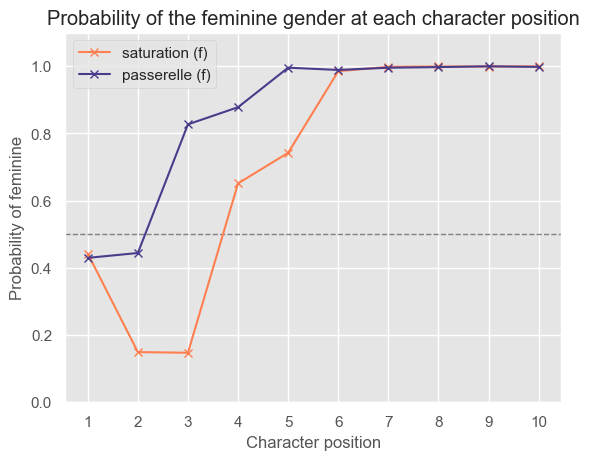

In [20]:
view_curve(['saturation', 'passerelle'], orth_preds, binary=True, gender='f', multiruns=False, scale=[0, 1.1])


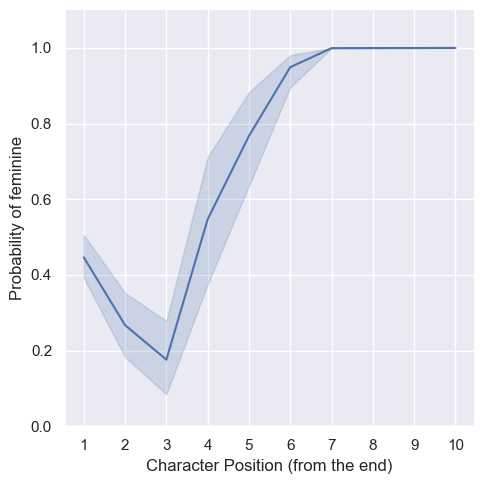

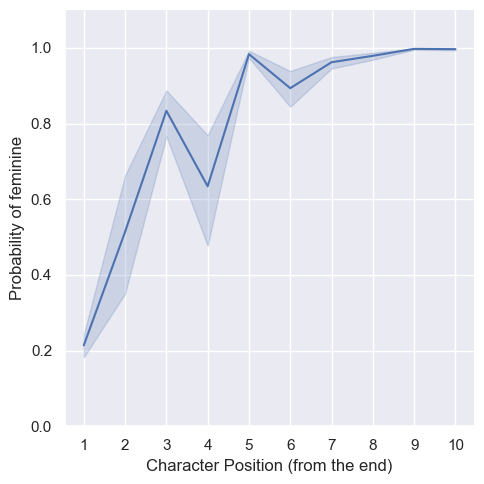

In [29]:
orth_preds_x10 = pd.read_csv('../results/echantinom_orth_preds_x10_new.csv')

sfx_avg = SuffixAverage(orth_preds_x10.query("Form == 'saturation'"), 'ion')
sfx_avg.plot(gender='f', title=False, scale=[0, 1.1])

sfx_avg = SuffixAverage(orth_preds_x10.query("Form == 'passerelle'"), 'elle')
sfx_avg.plot(gender='f', title=False, scale=[0, 1.1])